![ATARRI logos](img/logos.png)

# 2.5 Cross-section of dust concentration

#### Objective

The objective of this notebook is to create a cross-section of dust concentration data at a specific time step by using two sets of input coordinates.

## Introduction: Cross-sections

Just as we can use vertical profiles to monitor temporal changes across altitudes at a specific geographic point during a dust event, we can use a cross-section plot to monitor altitude variations at a specific time step between two points. This provides a few advantages, namely:

- Helps to identify layers and dust plumes.
- Provides insight into vertical and horizontal distributions of dust.
- Useful to validate model outputs against observations.

To achieve this, we will use the `metpy` library. [Metpy](https://unidata.github.io/MetPy/latest/userguide/startingguide.html) is a library that is primarily focused on reading, visualising and performing calculations with weather data. Among its different available tools, we have the `cross_section` function at our disposal, which obtains an interpolated cross-sectional slice through gridded data (find out more [here](https://unidata.github.io/MetPy/latest/api/generated/metpy.interpolate.cross_section.html#metpy.interpolate.cross_section)). Because it requires an `xarray.DataArray` with x and y coordinate dimensions, plus a crs coordinate, we are able to use our MONARCH forecasts as input data to create our own dust cross-section. We will learn how to do so below.

## Importing libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from matplotlib.colors import BoundaryNorm

from metpy.interpolate import cross_section

%matplotlib inline

In [2]:
from IPython.utils.io import capture_output
with capture_output():
    %run ../functions/functions1.ipynb

For this function to properly work, we will need the following parameters:

- Data: Our `.nc` MONARCH forecast as an `xarray.DataArray`, which must be 3D or higher to be interpolated.
- Start: Starting set of coordinates with latitude and longitude (degrees).
- End: End point set of coordinates with latitude and longitude (degrees).

The following parameters are optional:

- Steps: Number of points along the geodesic between our start and end points to be used in the cross section (the default is set to 100).
- Interp_type: Interpolation method, which can be either 'linear' or 'nearest' (the default is set to 'linear').

## Loading our data

For this exercise, we will select a dataset during which the dust event rises in intensity over our study area. We know that this happens around March 5-6, so we will load the corresponding .nc file. We also need to use CF parsing so the data is ready for use.

In [3]:
ds = xr.open_dataset('/shared/data/exp_to_interp/monarch/regional/3hourly/sconc_dust/sconc_dust_2025030412.nc', chunks={'time': 10, 'lat': 20, 'lon': 20})
ds = ds.metpy.parse_cf()
ds

Could not find variable corresponding to the value of grid_mapping: crs


<xarray.Dataset> Size: 2GB
Dimensions:     (time: 29, lev: 14, lat: 825, lon: 1650)
Coordinates:
  * time        (time) datetime64[ns] 232B 2025-03-04T12:00:00 ... 2025-03-08
  * lev         (lev) float64 112B 0.0 250.0 500.0 750.0 ... 8e+03 1e+04 1.2e+04
  * lat         (lat) float64 7kB -10.95 -10.85 -10.75 ... 71.25 71.35 71.45
  * lon         (lon) float64 13kB -62.95 -62.85 -62.75 ... 101.8 101.9 102.0
    metpy_crs   object 8B Projection: latitude_longitude
Data variables:
    sconc_dust  (time, lev, lat, lon) float32 2GB dask.array<chunksize=(10, 14, 20, 20), meta=np.ndarray>
Attributes:
    Domain:                     Regional
    Conventions:                CF-1.7
    comment:                    Generated on cirrus
    history_of_appended_files:  Tue Mar  4 18:03:58 2025: Appended file od550...
    NCO:                        netCDF Operators version 4.8.1 (Homepage = ht...
    history:                    Tue Feb 24 12:05:12 2026: ncatted -O -a stand...
    History:                    Translated to CF-1.0 Conventions by Netcdf-Ja...
    geospatial_lat_min:         -10.95
    geospatial_lat_max:         71.45
    geospatial_lon_min:         -62.95
    geospatial_lon_max:         101.95

## Setting our coordinates and time step

To comply with the start and end parameters, we will set our coordinates with which the cross-sectional line will be drawn. We have seen in our previous plots several dust plumes caused by the dust event, including over the Eastern Mediterranean. As this is our area of study, we will select our custom start and end points here.

In [4]:
start = (34.0, 30.9)    
end = (37.6, 38.1)

Next, we subset our data at our time step of interest.

In [5]:
ds = ds.isel(time=4)
ds

<xarray.Dataset> Size: 76MB
Dimensions:     (lev: 14, lat: 825, lon: 1650)
Coordinates:
  * lev         (lev) float64 112B 0.0 250.0 500.0 750.0 ... 8e+03 1e+04 1.2e+04
  * lat         (lat) float64 7kB -10.95 -10.85 -10.75 ... 71.25 71.35 71.45
  * lon         (lon) float64 13kB -62.95 -62.85 -62.75 ... 101.8 101.9 102.0
    time        datetime64[ns] 8B 2025-03-05
    metpy_crs   object 8B Projection: latitude_longitude
Data variables:
    sconc_dust  (lev, lat, lon) float32 76MB dask.array<chunksize=(14, 20, 20), meta=np.ndarray>
Attributes:
    Domain:                     Regional
    Conventions:                CF-1.7
    comment:                    Generated on cirrus
    history_of_appended_files:  Tue Mar  4 18:03:58 2025: Appended file od550...
    NCO:                        netCDF Operators version 4.8.1 (Homepage = ht...
    history:                    Tue Feb 24 12:05:12 2026: ncatted -O -a stand...
    History:                    Translated to CF-1.0 Conventions by Netcdf-Ja...
    geospatial_lat_min:         -10.95
    geospatial_lat_max:         71.45
    geospatial_lon_min:         -62.95
    geospatial_lon_max:         101.95

## Extract our cross-section

We do this by using the `cross_section` function and setting our x and y coordinates as `lat` and `lon`.

In [6]:
cross = cross_section(ds, start, end).set_coords(('lat', 'lon'))
cross

<xarray.Dataset> Size: 8kB
Dimensions:     (lev: 14, index: 100)
Coordinates:
  * lev         (lev) float64 112B 0.0 250.0 500.0 750.0 ... 8e+03 1e+04 1.2e+04
  * index       (index) int64 800B 0 1 2 3 4 5 6 7 8 ... 92 93 94 95 96 97 98 99
    time        datetime64[ns] 8B 2025-03-05
    metpy_crs   object 8B Projection: latitude_longitude
    lon         (index) float64 800B 30.9 30.97 31.04 31.11 ... 37.95 38.02 38.1
    lat         (index) float64 800B 34.0 34.04 34.08 34.12 ... 37.53 37.57 37.6
Data variables:
    sconc_dust  (lev, index) float32 6kB dask.array<chunksize=(2, 100), meta=np.ndarray>
Attributes:
    Domain:                     Regional
    Conventions:                CF-1.7
    comment:                    Generated on cirrus
    history_of_appended_files:  Tue Mar  4 18:03:58 2025: Appended file od550...
    NCO:                        netCDF Operators version 4.8.1 (Homepage = ht...
    history:                    Tue Feb 24 12:05:12 2026: ncatted -O -a stand...
    History:                    Translated to CF-1.0 Conventions by Netcdf-Ja...
    geospatial_lat_min:         -10.95
    geospatial_lat_max:         71.45
    geospatial_lon_min:         -62.95
    geospatial_lon_max:         101.95

MetPy requires units to be attached to arrays in order to pass its functions. As we have seen before, our MONARCH `sconc_dust` .nc files are produced in kg/m³, which we often manually transform into µg/m³. However, another advantage of using this library is its functionality to convert units, which modifies both the values themselves and the metadata of our in-memory dataset. To make this conversion, we will follow these steps:

- Modify the `.attrs['units']` from `kgm-3` to `kg m-3`. We need to add this extra space because our original format is not recognised in the list of available units in metpy.
- Apply the `.quantify()` method to convert to a unit-aware type, so we can continue using xarray operations while preserving unit correctness. Because we have chunked our data set, our data will remain lazy-loaded, otherwise this step directly loads the dataset in-memory.
- Use the `.convert_units()` method to change our units to µg/m³.

In [7]:
cross['sconc_dust'].attrs['units'] = 'kg m-3'
cross = cross.metpy.quantify()
cross['sconc_dust'] = cross['sconc_dust'].metpy.convert_units('microgram / meter ** 3') * 2
cross

<xarray.Dataset> Size: 8kB
Dimensions:     (lev: 14, index: 100)
Coordinates:
  * lev         (lev) float64 112B 0.0 250.0 500.0 750.0 ... 8e+03 1e+04 1.2e+04
  * index       (index) int64 800B 0 1 2 3 4 5 6 7 8 ... 92 93 94 95 96 97 98 99
    time        datetime64[ns] 8B 2025-03-05
    metpy_crs   object 8B Projection: latitude_longitude
    lon         (index) float64 800B 30.9 30.97 31.04 31.11 ... 37.95 38.02 38.1
    lat         (index) float64 800B 34.0 34.04 34.08 34.12 ... 37.53 37.57 37.6
Data variables:
    sconc_dust  (lev, index) float32 6kB <Quantity(dask.array<mul, shape=(14,...
Attributes:
    Domain:                     Regional
    Conventions:                CF-1.7
    comment:                    Generated on cirrus
    history_of_appended_files:  Tue Mar  4 18:03:58 2025: Appended file od550...
    NCO:                        netCDF Operators version 4.8.1 (Homepage = ht...
    history:                    Tue Feb 24 12:05:12 2026: ncatted -O -a stand...
    History:                    Translated to CF-1.0 Conventions by Netcdf-Ja...
    geospatial_lat_min:         -10.95
    geospatial_lat_max:         71.45
    geospatial_lon_min:         -62.95
    geospatial_lon_max:         101.95

Our last step before plotting is to add our plotting input parameters: `lat`, `lon`, `lev`, `concdu`, `cmap_bdrc`, `concdu_norm` and `concdu_levels`.

In [8]:
lat = cross['lat']
lon = cross['lon']
lev = cross['lev']
concdu = cross['sconc_dust']

cmap_bdrc = get_cmap_bdrc()
concdu_norm = get_normalised_bdrc("sconc_dust", cmap_bdrc)
concdu_levels = concdu_norm.boundaries

## Plotting our cross-section

We will plot the cross section as a `contourf` plot, similar to our vertical section. In addition, it is useful to add an inset so we can identify where the cross-section line lies on the map. For the inset we need to set:

- CRS
- Inset axes relative to the main figure
- Path of the cross-section
- Extent adjustment. To ensure a visual consistency in size and position, prevent overlaps and shifting in the inset plot layouts if we change our input coordinates, we will make use of the custom function `set_inset_extent()`.

Our result is a cross-section of dust concentration on `20250306` at `00:00:00UTC`, with a geographic inset showcasing the cross-section path.

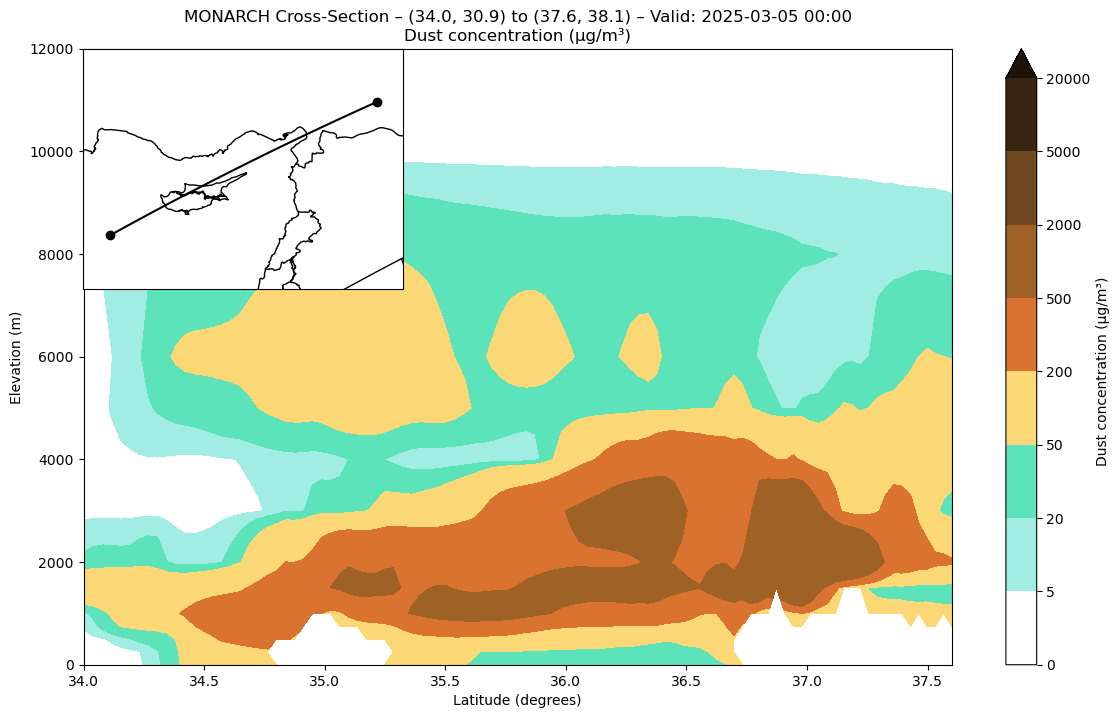

In [9]:
# Define figure and axes
fig = plt.figure(figsize=(14, 8))
ax = plt.axes()

# Plot the cross-section using contourf
conc_contour = ax.contourf(
    lat, 
    lev, 
    concdu,
    levels=concdu_levels,
    cmap=cmap_bdrc,
    norm=concdu_norm,
    extend='max'
)
conc_colorbar = fig.colorbar(conc_contour)

# Define the CRS and inset axes
data_crs = ds['metpy_crs'].metpy.cartopy_crs
ax_inset = fig.add_axes([0.099, 0.58, 0.28, 0.3], projection=data_crs)

# Plot the path of the cross section and set zoom parameters
endpoints = data_crs.transform_points(ccrs.Geodetic(), *np.vstack([start, end]).transpose()[::-1])
ax_inset.scatter(endpoints[:, 0], endpoints[:, 1], c='k', zorder=2)
ax_inset.plot(lon,
              lat,
              c='k',
              zorder=2)
set_inset_extent(ax_inset, cross) # set dynamic inset


# Add geographic features
ax_inset.add_feature(cfeature.BORDERS, linewidth=1, edgecolor="black")
ax_inset.coastlines()

# Set the titles and axes labels
ax_inset.set_title('')
ax.set_title(f'MONARCH Cross-Section \u2013 {start} to {end} \u2013 '
             f'Valid: {cross["time"].dt.strftime("%Y-%m-%d %H:%M").item()}\n'
             'Dust concentration (µg/m³)')
ax.set_ylabel('Elevation (m)')
ax.set_xlabel('Latitude (degrees)')
conc_colorbar.set_label('Dust concentration (µg/m³)')

#ax.invert_xaxis()  # This flips the latitude axis direction

plt.show()

## Extra: Adding AOD data to our inset map

To further help our analysis, we can add dust data to our inset map. In the following example, we will add dust optical depth at 550nm.

We will need to upload our dataset corresponding to the same date.

In [11]:
ds_aod = xr.open_dataset('/shared/data/exp_to_interp/monarch/regional/3hourly/od550_dust/od550_dust_2025030400.nc')
ds_aod

<xarray.Dataset> Size: 158MB
Dimensions:     (time: 29, lat: 825, lon: 1650)
Coordinates:
  * time        (time) datetime64[ns] 232B 2025-03-04T12:00:00 ... 2025-03-08
  * lat         (lat) float64 7kB -10.95 -10.85 -10.75 ... 71.25 71.35 71.45
  * lon         (lon) float64 13kB -62.95 -62.85 -62.75 ... 101.8 101.9 102.0
Data variables:
    od550_dust  (time, lat, lon) float32 158MB ...
Attributes:
    Domain:                     Regional
    Conventions:                CF-1.7
    comment:                    Generated on cirrus
    history_of_appended_files:  Tue Mar  4 18:03:58 2025: Appended file od550...
    NCO:                        netCDF Operators version 4.8.1 (Homepage = ht...
    history:                    Tue Feb 24 12:05:12 2026: ncatted -O -a stand...
    History:                    Translated to CF-1.0 Conventions by Netcdf-Ja...
    geospatial_lat_min:         -10.95
    geospatial_lat_max:         71.45
    geospatial_lon_min:         -62.95
    geospatial_lon_max:         101.95

We need to add specific variables for our inset:
- `dod_norm`
- `ds_aod`: We will subset for the same time step as our dust concentration data.
- `lon_aod`
- `lat_aod`

In [12]:
ds_aod = ds_aod['od550_dust'].isel(time=4)
lon_aod = ds_aod['lon']
lat_aod = ds_aod['lat']

dod_norm = get_normalised_bdrc("od550_dust", cmap_bdrc)

We will create a `pcolormesh` plot with dust AOD. We will need to apply the same plotting structure that we have seen in the previous notebooks. We will also customise our inset so the plot looks better. We will move it to the top-right of the plot so it does not obstruct any of the plotted data, and we will add a white outline.

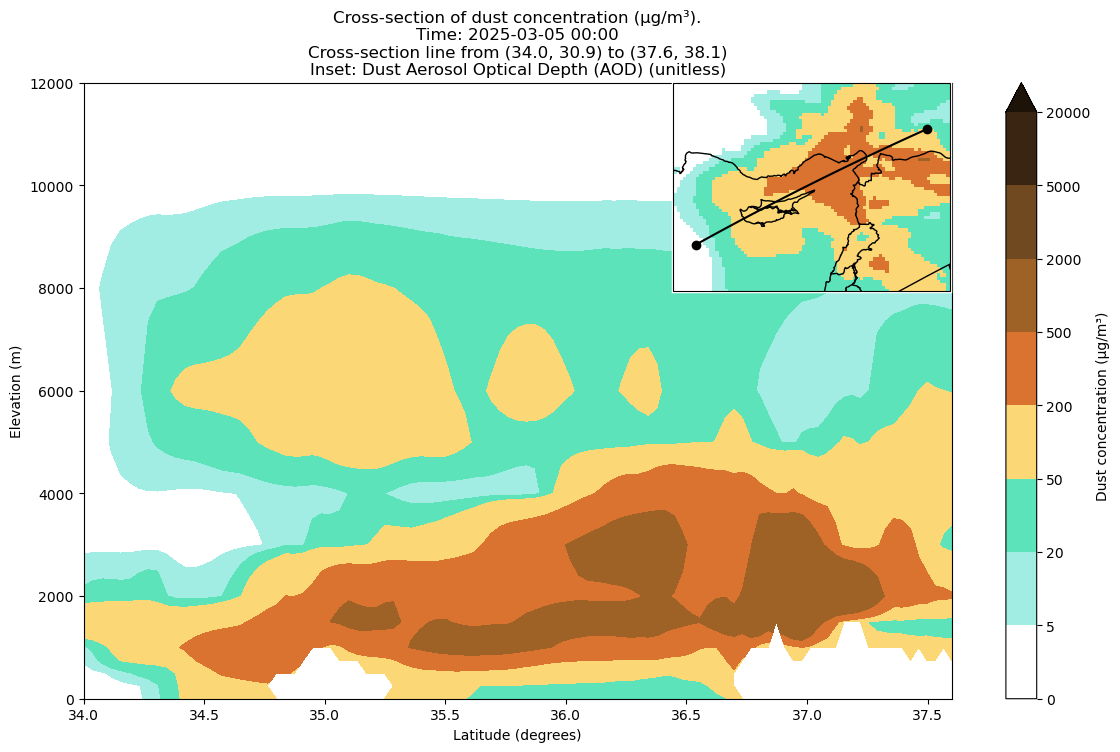

In [13]:
# Define figure and axes
fig = plt.figure(figsize=(14, 8))
ax = plt.axes()

# Plot the cross-section using contourf
conc_contour = ax.contourf(
    lat, 
    lev, 
    concdu,
    levels=concdu_levels,
    cmap=cmap_bdrc,
    norm=concdu_norm,
    extend='max'
)
conc_colorbar = fig.colorbar(conc_contour)

# Define the CRS and inset axes
data_crs = ds['metpy_crs'].metpy.cartopy_crs
ax_inset = fig.add_axes([0.505, 0.62, 0.28, 0.26], projection=data_crs)

# Plot dust AOD inset as pcolormesh
mesh = ax_inset.pcolormesh(lon_aod,
                           lat_aod,
                           ds_aod,
                           cmap=cmap_bdrc,
                           norm=dod_norm,
                           shading='auto',
                           transform=ccrs.PlateCarree()
                          )

# Plot the path of the cross section and set zoom parameters
endpoints = data_crs.transform_points(ccrs.Geodetic(), *np.vstack([start, end]).transpose()[::-1])
ax_inset.scatter(endpoints[:, 0], endpoints[:, 1], c='k', zorder=2)
ax_inset.plot(lon,
              lat,
              c='k',
              zorder=2)
set_inset_extent(ax_inset, cross) # set dynamic inset


# Add geographic features
ax_inset.add_feature(cfeature.BORDERS, linewidth=1, edgecolor="black")
ax_inset.coastlines()

# Set the titles and axes labels
ax.set_title(
    'Cross-section of dust concentration (µg/m³).\n'
    f'Time: {cross["time"].dt.strftime("%Y-%m-%d %H:%M").item()}\n'
    f'Cross-section line from {start} to {end}\n'
    f'Inset: Dust Aerosol Optical Depth (AOD) (unitless)'
)
ax.set_ylabel('Elevation (m)')
ax.set_xlabel('Latitude (degrees)')
conc_colorbar.set_label('Dust concentration (µg/m³)')

# Customising the inse
ax_inset.patch.set_edgecolor('white')
ax_inset.patch.set_linewidth(2.5)


## References and further reading

- MetPy: Getting Started [documentation](https://unidata.github.io/MetPy/latest/userguide/startingguide.html)
- MetPy `.interpolate.cross_section` [documentation](https://unidata.github.io/MetPy/latest/api/generated/metpy.interpolate.cross_section.html#metpy.interpolate.cross_section)
- MetPy Cross Section Analysis [example](https://unidata.github.io/MetPy/latest/examples/cross_section.html#sphx-glr-examples-cross-section-py)
- MetPy [Units Tutorial](https://unidata.github.io/MetPy/latest/tutorials/unit_tutorial.html)
- Matplotlib `.pyplot.contourf` [documentation](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.contourf.html)
- Matplotlib `.pyplot.pcolormesh` [documentation](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.pcolormesh.html)

May, R. M., Goebbert, K. H., Thielen, J. E., Leeman, J. R., Camron, M. D., Bruick, Z.,
    Bruning, E. C., Manser, R. P., Arms, S. C., and Marsh, P. T., 2022: MetPy: A
    Meteorological Python Library for Data Analysis and Visualization. Bull. Amer. Meteor.
    Soc., 103, E2273-E2284, https://doi.org/10.1175/BAMS-D-21-0125.1.

<table style="width:100%;">
    <tr>
        <td style="text-align: center;"><a href="VT2-4-vertical_profiles.ipynb" style="font-size: 18px;">⬅ Previous</a></td>
        <td style="text-align: center;"><a href="VT2-6-Workshop.ipynb" style="font-size: 18px;">Next ➡</a></td>
    </tr
</table>